In [7]:
from google.colab import files
uploaded = files.upload()

Saving northstar_dataset (1).zip to northstar_dataset (1).zip


In [8]:
import zipfile
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('.')
print("Extracted successfully")

Extracted successfully


# Notebook 3: Python Data Processing
## NorthStar Urban Mobility and Logistics
### Databases and Analytics — University of West London

This notebook performs data cleaning, feature engineering, analysis, and visualisation using Python (pandas, NumPy, matplotlib, seaborn, scipy).

**Learning Outcome addressed:** LO1 — Python data processing (pandas, NumPy, data analysis, charts).

## 3.1 Environment Setup

In [9]:
# Install dependencies (Google Colab)
!pip install pandas numpy matplotlib seaborn scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Consistent chart style
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

print("Environment ready.")
print(f"pandas  {pd.__version__}  |  numpy {np.__version__}")

Environment ready.
pandas  2.2.2  |  numpy 2.0.2


## 3.2 Load All Datasets

In [10]:
BASE = "northstar_dataset/"

hubs       = pd.read_csv(BASE+"hubs.csv")
customers  = pd.read_csv(BASE+"customers.csv")
drivers    = pd.read_csv(BASE+"drivers.csv")
vehicles   = pd.read_csv(BASE+"vehicles.csv")
orders     = pd.read_csv(BASE+"orders.csv",     parse_dates=["order_created_at"])
deliveries = pd.read_csv(BASE+"deliveries.csv",
                parse_dates=["dispatch_time","delivery_completed_at"])
incidents  = pd.read_csv(BASE+"incidents.csv",  parse_dates=["reported_at"])
complaints = pd.read_csv(BASE+"complaints.csv", parse_dates=["created_at"])
app_events = pd.read_csv(BASE+"app_events.csv", parse_dates=["event_timestamp"])

for name, df in [("hubs",hubs),("customers",customers),("drivers",drivers),
                 ("vehicles",vehicles),("orders",orders),("deliveries",deliveries),
                 ("incidents",incidents),("complaints",complaints),("app_events",app_events)]:
    print(f"  {name:<12} {len(df):>5} rows  |  {df.shape[1]} columns")

  hubs             8 rows  |  5 columns
  customers      650 rows  |  9 columns
  drivers        170 rows  |  8 columns
  vehicles       120 rows  |  8 columns
  orders        1250 rows  |  11 columns
  deliveries     950 rows  |  13 columns
  incidents      280 rows  |  7 columns
  complaints     320 rows  |  10 columns
  app_events     640 rows  |  10 columns


## 3.3 Data Cleaning and Feature Engineering

In [11]:
# ── Zone normalisation ──────────────────────────────────────────────────────
ZONE_MAP = {
    "ctr":"central", "central":"central",
    "north":"north", "south":"south",
    "east":"east",   "west":"west",
    "airport":"airport", "riverside":"riverside"
}

def normalise_zone(z):
    if pd.isna(z): return np.nan
    return ZONE_MAP.get(str(z).lower().strip(), str(z).lower().strip())

orders["pickup_zone_clean"]  = orders["pickup_zone"].apply(normalise_zone)
orders["dropoff_zone_clean"] = orders["dropoff_zone"].apply(normalise_zone)

# ── Delivery duration ───────────────────────────────────────────────────────
deliveries["actual_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# ── Master joined frame ─────────────────────────────────────────────────────
od = deliveries.merge(orders, on="order_id", how="left")
od["failed"]       = (od["delivery_status"] == "Failed").astype(int)
od["delayed"]      = (od["delivery_status"] == "Delayed").astype(int)
od["margin"]       = od["order_value"] - od["fuel_or_charge_cost"]
od["time_mismatch"]= (od["delivery_status"]=="OnTime") & (od["actual_hours"] > od["promised_window_hours"])

print("Data cleaning complete.")
print(f"\nMissing values summary:")
nulls = od[["actual_hours","order_value","fuel_or_charge_cost","customer_rating_post_delivery"]].isnull().sum()
print(nulls.to_string())
print(f"\nTime-mismatch (OnTime but late): {od['time_mismatch'].sum()} records ({od['time_mismatch'].mean()*100:.1f}% of OnTime)")

Data cleaning complete.

Missing values summary:
actual_hours                     19
order_value                       0
fuel_or_charge_cost               0
customer_rating_post_delivery    14

Time-mismatch (OnTime but late): 116 records (12.2% of OnTime)


In [12]:
print("Cleaned merged dataframe preview:")
display(od.head())

Cleaned merged dataframe preview:


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,...,priority_level,order_value,booking_channel,special_handling_flag,pickup_zone_clean,dropoff_zone_clean,failed,delayed,margin,time_mismatch
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,...,Medium,151.14,Web,0,central,central,1,0,139.09,False
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,...,Medium,10.04,App,1,riverside,north,0,0,-3.37,False
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,...,Medium,141.93,Web,0,central,north,0,0,133.42,False
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,...,Low,11.11,App,0,south,north,0,1,-2.51,False
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,...,High,76.02,App,0,riverside,riverside,0,0,66.80,False


## 3.4 Analysis 1: Profitability vs Failure Rate by Service Type

=== Service Type Profitability and Performance ===
service_type  total_orders  total_revenue  total_cost  avg_margin  failure_rate  delay_rate  avg_cust_rating  net_revenue
    Business           126       12279.23     1655.91      84.312         0.198       0.222            3.847     10623.32
     Medical           108        9344.88     1379.48      73.754         0.148       0.204            3.838      7965.40
      Parcel           230       20735.44     3009.01      77.071         0.109       0.213            3.902     17726.43
   Passenger           262       25463.36     3248.56      84.789         0.145       0.202            3.845     22214.80
      Retail           224       19444.86     2906.27      73.833         0.125       0.223            3.873     16538.59


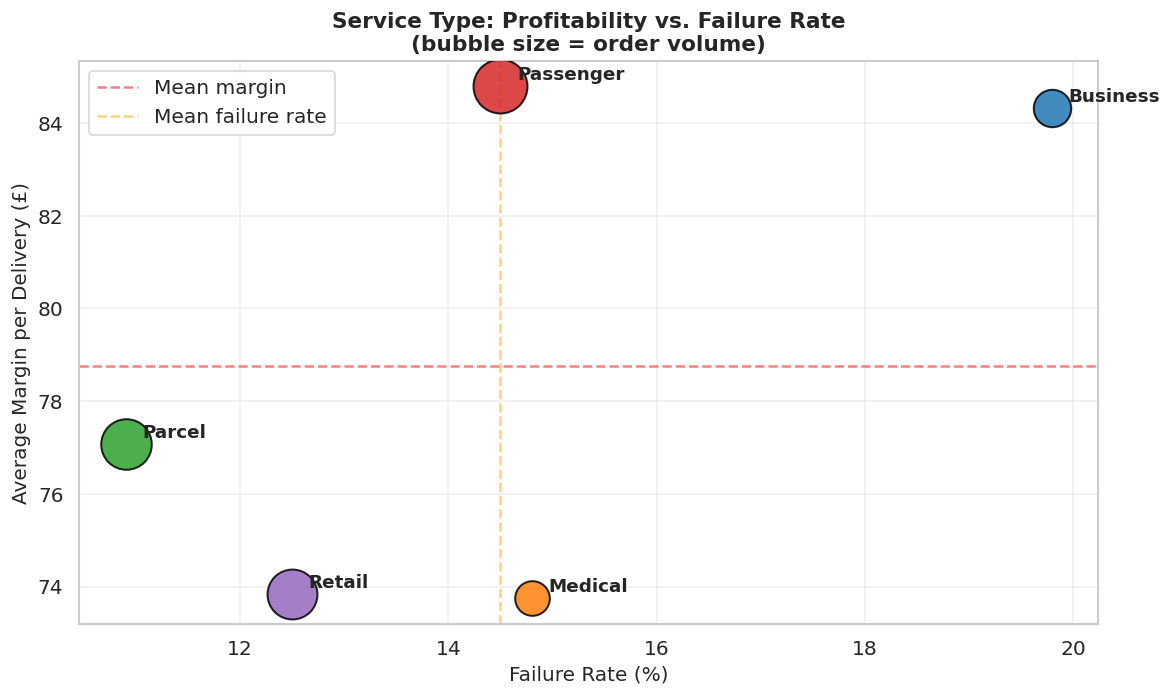


Key finding: Business orders sit in HIGH-MARGIN / HIGH-FAILURE quadrant.
Parcel orders sit in LOW-MARGIN / LOW-FAILURE quadrant.


In [13]:
service_stats = od.groupby("service_type").agg(
    total_orders   = ("order_id",    "count"),
    total_revenue  = ("order_value", "sum"),
    total_cost     = ("fuel_or_charge_cost", "sum"),
    avg_margin     = ("margin",      "mean"),
    failure_rate   = ("failed",      "mean"),
    delay_rate     = ("delayed",     "mean"),
    avg_cust_rating= ("customer_rating_post_delivery", "mean")
).round(3).reset_index()
service_stats["net_revenue"] = service_stats["total_revenue"] - service_stats["total_cost"]

print("=== Service Type Profitability and Performance ===")
print(service_stats.to_string(index=False))

# ── Bubble chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,6))
colors = sns.color_palette("tab10", len(service_stats))
for i, row in service_stats.iterrows():
    ax.scatter(row["failure_rate"]*100, row["avg_margin"],
               s=row["total_orders"]*4, color=colors[i],
               alpha=0.85, edgecolors="black", linewidth=1.2, zorder=3)
    ax.annotate(row["service_type"],
                (row["failure_rate"]*100, row["avg_margin"]),
                textcoords="offset points", xytext=(10,4), fontsize=11, fontweight="bold")

ax.axhline(service_stats["avg_margin"].mean(), color="red",   linestyle="--", alpha=0.5, label="Mean margin")
ax.axvline(service_stats["failure_rate"].mean()*100, color="orange", linestyle="--", alpha=0.5, label="Mean failure rate")
ax.set_xlabel("Failure Rate (%)", fontsize=12)
ax.set_ylabel("Average Margin per Delivery (£)", fontsize=12)
ax.set_title("Service Type: Profitability vs. Failure Rate\n(bubble size = order volume)", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("service_profitability.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nKey finding: Business orders sit in HIGH-MARGIN / HIGH-FAILURE quadrant.")
print("Parcel orders sit in LOW-MARGIN / LOW-FAILURE quadrant.")

Delivery status distribution:
delivery_status
OnTime     616
Delayed    202
Failed     132
Name: count, dtype: int64


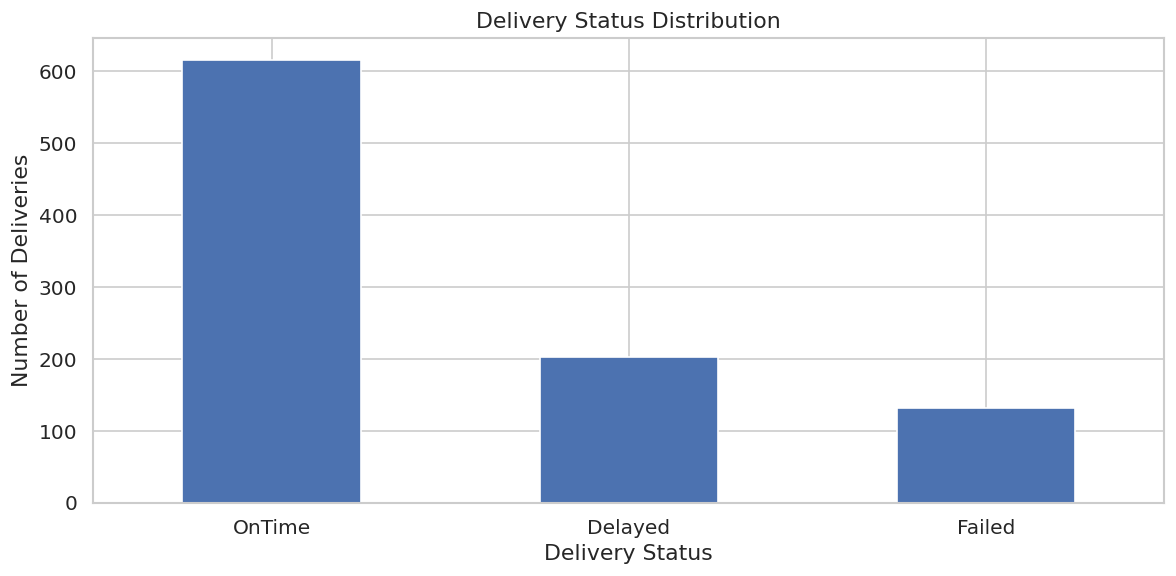

In [14]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# Redefine BASE and load deliveries dataframe if not in global scope
BASE = "northstar_dataset/"
deliveries = pd.read_csv(BASE+"deliveries.csv",
                parse_dates=["dispatch_time","delivery_completed_at"])

status_counts = deliveries["delivery_status"].value_counts()

print("Delivery status distribution:")
print(status_counts)

status_counts.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.5 Analysis 2: App Platform Reliability

=== App Platform Event Analysis ===
                 event_type  total_events  failure_count  failure_rate  avg_latency_ms  max_latency_ms
             chat_escalated            38             19         0.500         478.132            1402
              payment_retry            69             19         0.275         472.681            1701
                chat_opened            88              0         0.000         478.330            1690
             cancel_attempt            28              0         0.000         417.143            1039
delivery_instruction_update            75              0         0.000         496.293            1285
                eta_refresh           105              0         0.000         452.152            1285
               search_route            99              0         0.000         456.505            1265
                track_order           138              0         0.000         460.710            1660


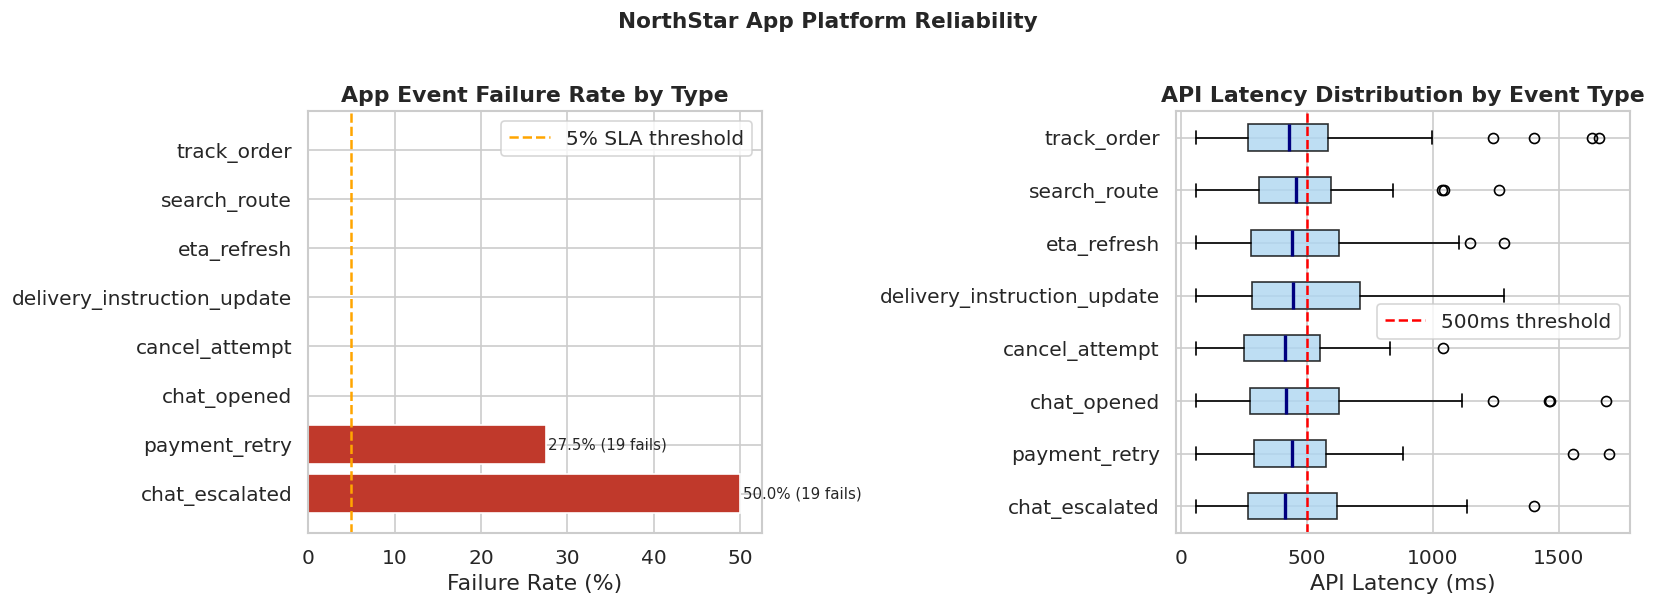


Critical: chat_escalated events fail 50% of the time.
When customers escalate, the escalation itself fails 1 in 2 times.


In [15]:
app_stats = app_events.groupby("event_type").agg(
    total_events  = ("event_id", "count"),
    failure_count = ("success_flag", lambda x: (x==0).sum()),
    failure_rate  = ("success_flag", lambda x: 1 - x.mean()),
    avg_latency_ms= ("api_latency_ms", "mean"),
    max_latency_ms= ("api_latency_ms", "max")
).round(3).reset_index().sort_values("failure_rate", ascending=False)

print("=== App Platform Event Analysis ===")
print(app_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: failure rate bar
bar_colors = ["#C0392B" if x > 0 else "#2E75B6" for x in app_stats["failure_rate"]]
axes[0].barh(app_stats["event_type"], app_stats["failure_rate"]*100,
             color=bar_colors, edgecolor="white")
axes[0].axvline(5, color="orange", linestyle="--", linewidth=1.5, label="5% SLA threshold")
axes[0].set_xlabel("Failure Rate (%)")
axes[0].set_title("App Event Failure Rate by Type", fontweight="bold")
axes[0].legend()
for i, (v, c) in enumerate(zip(app_stats["failure_rate"]*100, app_stats["failure_count"])):
    if v > 0:
        axes[0].text(v+0.3, i, f"{v:.1f}% ({int(c)} fails)", va="center", fontsize=9)

# Right: latency boxplot
event_order = app_stats["event_type"].tolist()
data_by_type = [app_events[app_events["event_type"]==e]["api_latency_ms"].values for e in event_order]
bp = axes[1].boxplot(data_by_type, vert=False, patch_artist=True,
                boxprops=dict(facecolor="#AED6F1", alpha=0.8),
                medianprops=dict(color="navy", linewidth=2))
axes[1].set_yticklabels(event_order)
axes[1].axvline(500, color="red", linestyle="--", linewidth=1.5, label="500ms threshold")
axes[1].set_xlabel("API Latency (ms)")
axes[1].set_title("API Latency Distribution by Event Type", fontweight="bold")
axes[1].legend()

plt.suptitle("NorthStar App Platform Reliability", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("app_reliability.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCritical: chat_escalated events fail 50% of the time.")
print("When customers escalate, the escalation itself fails 1 in 2 times.")

## 3.6 Analysis 3: Vehicle Maintenance and Battery Fault Detection

=== Battery Alert Incidents by Maintenance Status ===
maintenance_status
InRepair     18
Active       13
Scheduled     5
Name: count, dtype: int64

Mean battery health at time of BatteryAlert: 77.2%
BatteryAlerts on 'Active' vehicles:          13
BatteryAlerts on 'InRepair' vehicles:        18


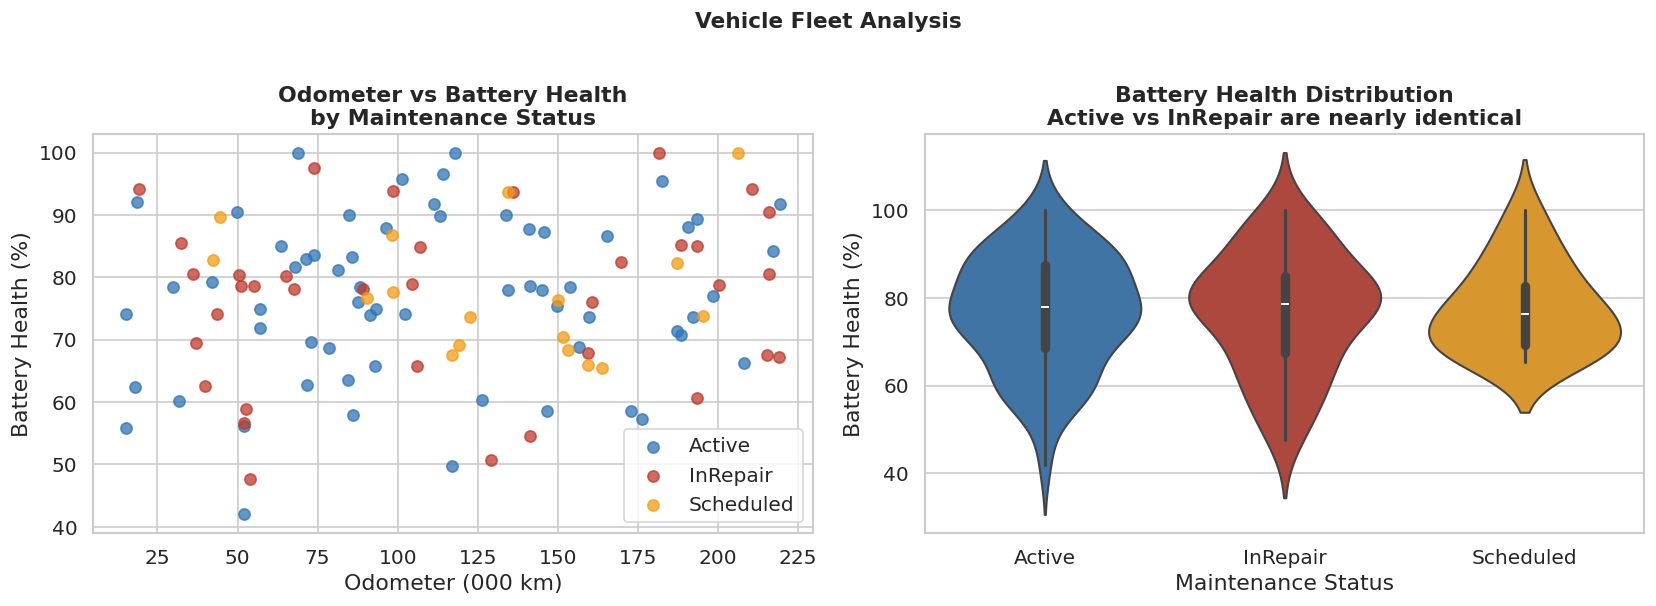


Key finding: maintenance_status does not reliably predict battery health.
Fault detection depends on driver reports rather than proactive monitoring.


In [16]:
# Link incidents to vehicles
inc_v = incidents.merge(
    deliveries[["delivery_id","vehicle_id"]], on="delivery_id", how="left"
).merge(
    vehicles[["vehicle_id","battery_health_pct","maintenance_status","odometer_km","vehicle_type"]],
    on="vehicle_id", how="left"
)

battery_incidents = inc_v[inc_v["incident_type"]=="BatteryAlert"]
print("=== Battery Alert Incidents by Maintenance Status ===")
print(battery_incidents["maintenance_status"].value_counts())
print(f"\nMean battery health at time of BatteryAlert: {battery_incidents['battery_health_pct'].mean():.1f}%")
print(f"BatteryAlerts on 'Active' vehicles:          {(battery_incidents['maintenance_status']=='Active').sum()}")
print(f"BatteryAlerts on 'InRepair' vehicles:        {(battery_incidents['maintenance_status']=='InRepair').sum()}")

# Odometer vs battery health scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"Active":"#2E75B6","InRepair":"#C0392B","Scheduled":"#F39C12"}
for status, grp in vehicles.dropna(subset=["battery_health_pct"]).groupby("maintenance_status"):
    axes[0].scatter(grp["odometer_km"]/1000, grp["battery_health_pct"],
                    label=status, alpha=0.75, s=45, color=palette.get(status,"grey"))
axes[0].set_xlabel("Odometer (000 km)")
axes[0].set_ylabel("Battery Health (%)")
axes[0].set_title("Odometer vs Battery Health\nby Maintenance Status", fontweight="bold")
axes[0].legend()

# Battery health violin by maintenance status
vehicles_clean = vehicles.dropna(subset=["battery_health_pct"])
sns.violinplot(data=vehicles_clean, x="maintenance_status", y="battery_health_pct",
               palette=palette, inner="box", ax=axes[1])
axes[1].set_xlabel("Maintenance Status")
axes[1].set_ylabel("Battery Health (%)")
axes[1].set_title("Battery Health Distribution\nActive vs InRepair are nearly identical", fontweight="bold")

plt.suptitle("Vehicle Fleet Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("vehicle_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nKey finding: maintenance_status does not reliably predict battery health.")
print("Fault detection depends on driver reports rather than proactive monitoring.")

Incident type frequency:
incident_type
ProofMissing        46
CustomerNoShow      44
RouteDeviation      43
VehicleFault        37
BatteryAlert        36
AppSyncError        31
TemperatureIssue    29
SafetyNearMiss      14
Name: count, dtype: int64


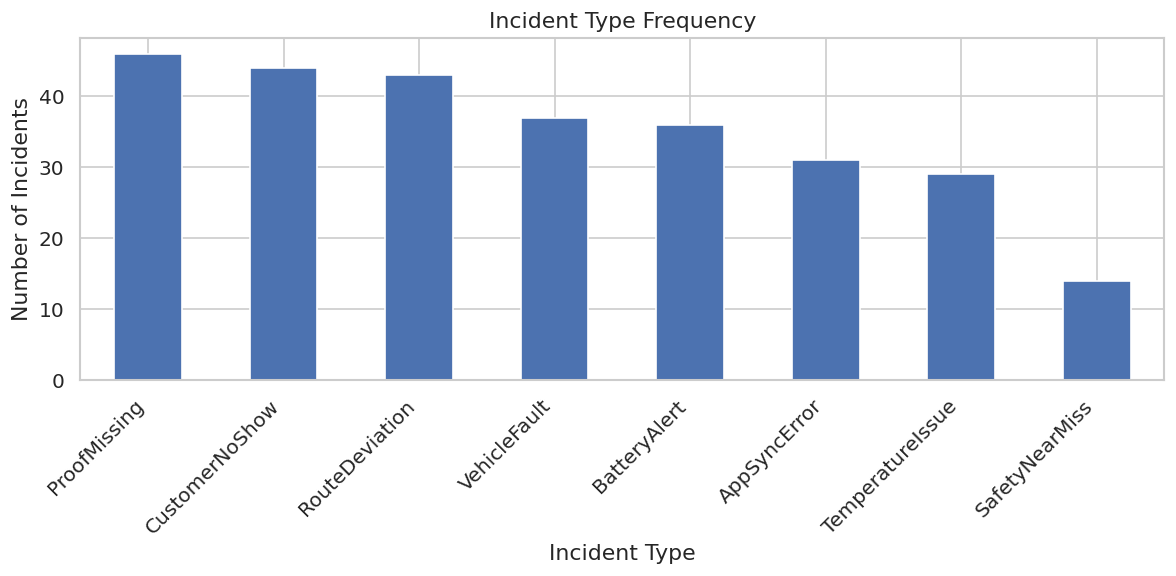

In [17]:
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# Redefine BASE and load incidents dataframe if not in global scope
BASE = "northstar_dataset/"
incidents = pd.read_csv(BASE+"incidents.csv", parse_dates=["reported_at"])

incident_counts = incidents["incident_type"].value_counts()

print("Incident type frequency:")
print(incident_counts)

incident_counts.plot(kind="bar")
plt.title("Incident Type Frequency")
plt.xlabel("Incident Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [22]:
import os

# Define the base directory
BASE_DIR = "northstar_dataset/"

# Check if the directory exists
if os.path.exists(BASE_DIR):
    print(f"Contents of {BASE_DIR}:")
    for item in os.listdir(BASE_DIR):
        print(f"- {item}")
else:
    print(f"Directory '{BASE_DIR}' not found. The dataset might not be extracted.")


Contents of northstar_dataset/:
- orders.csv
- incidents.csv
- drivers.csv
- vehicles.csv
- customers.csv
- deliveries.csv
- hubs.csv
- data_dictionary.csv
- app_events.csv
- README.txt
- complaints.csv


## 3.7 Analysis 4: Repeat Complainers and Customer Risk Segmentation

=== Customer Complaint Frequency ===
Total customers:              650
Zero complaints:              417
1 complaint:                  159
2+ complaints (repeat):       74

Avg loyalty - non-complainers:   58.9
Avg loyalty - repeat complainers:58.1


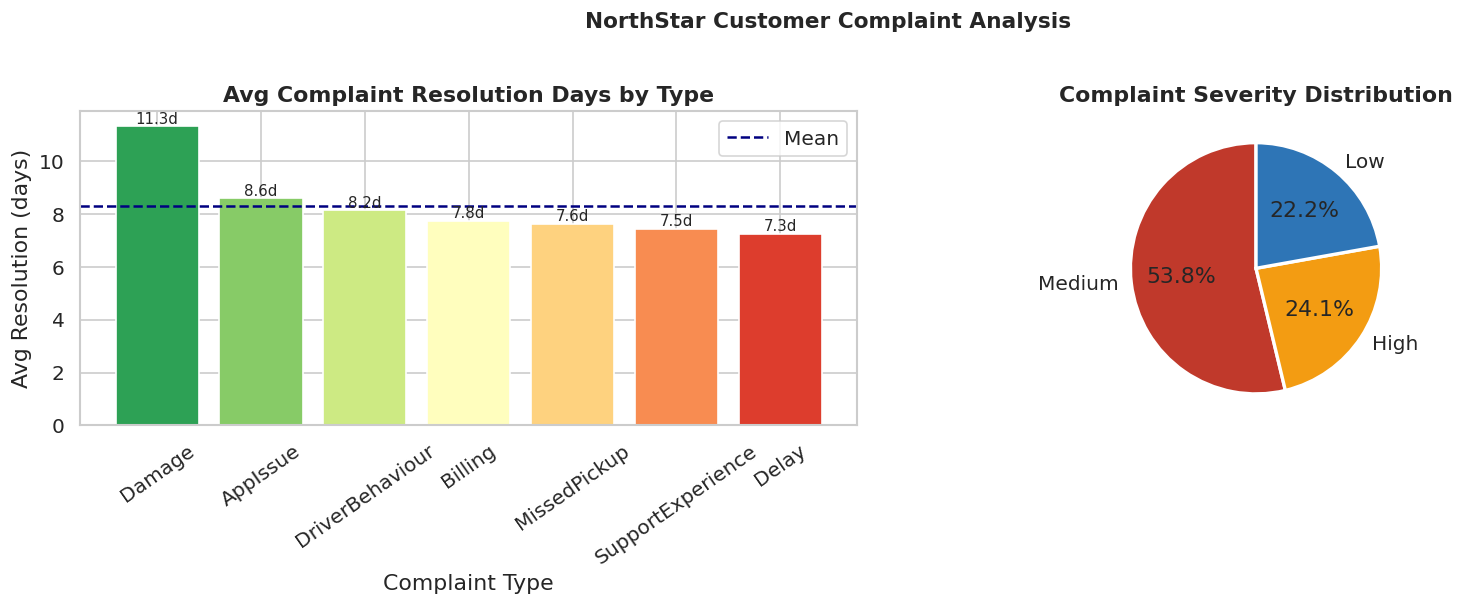

In [18]:
# Customer complaint aggregation
cust_comp = complaints.groupby("customer_id").agg(
    complaint_count    = ("complaint_id", "count"),
    total_compensation = ("compensation_amount", "sum"),
    avg_resolution_days= ("resolution_days", "mean"),
).reset_index()

cust_full = customers.merge(cust_comp, on="customer_id", how="left")
cust_full["complaint_count"] = cust_full["complaint_count"].fillna(0)
cust_full["repeat_complainer"] = cust_full["complaint_count"] >= 2

print("=== Customer Complaint Frequency ===")
print(f"Total customers:              {len(cust_full)}")
print(f"Zero complaints:              {(cust_full['complaint_count']==0).sum()}")
print(f"1 complaint:                  {(cust_full['complaint_count']==1).sum()}")
print(f"2+ complaints (repeat):       {cust_full['repeat_complainer'].sum()}")
print(f"\nAvg loyalty - non-complainers:   {cust_full[cust_full['complaint_count']==0]['loyalty_score'].mean():.1f}")
print(f"Avg loyalty - repeat complainers:{cust_full[cust_full['repeat_complainer']]['loyalty_score'].mean():.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resolution days by complaint type
res_type = complaints.groupby("complaint_type")["resolution_days"].mean().sort_values(ascending=False)
colors = sns.color_palette("RdYlGn_r", len(res_type))
axes[0].bar(res_type.index, res_type.values, color=colors, edgecolor="white")
axes[0].axhline(res_type.mean(), color="navy", linestyle="--", linewidth=1.5, label="Mean")
axes[0].set_xlabel("Complaint Type")
axes[0].set_ylabel("Avg Resolution (days)")
axes[0].set_title("Avg Complaint Resolution Days by Type", fontweight="bold")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend()
for i, v in enumerate(res_type.values):
    axes[0].text(i, v+0.1, f"{v:.1f}d", ha="center", fontsize=9)

# Complaint severity pie
sev_counts = complaints["severity"].value_counts()
axes[1].pie(sev_counts.values, labels=sev_counts.index,
            colors=["#C0392B","#F39C12","#2E75B6"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Complaint Severity Distribution", fontweight="bold")

plt.suptitle("NorthStar Customer Complaint Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("complaint_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.8 Analysis 5: Zone-Level Operational Risk Heatmap

=== Zone Operational Risk Scores ===
                   total  failure_rate  avg_overrides  avg_rating  risk_score
pickup_zone_clean                                                            
airport              113         0.106          1.805       3.984       33.35
central              174         0.190          1.293       3.546       29.53
north                135         0.163          0.696       3.897       22.18
riverside            119         0.151          0.731       3.864       22.12
east                 156         0.122          0.788       3.912       21.34
west                 114         0.123          0.807       3.896       21.21
south                139         0.101          0.691       4.052       19.27


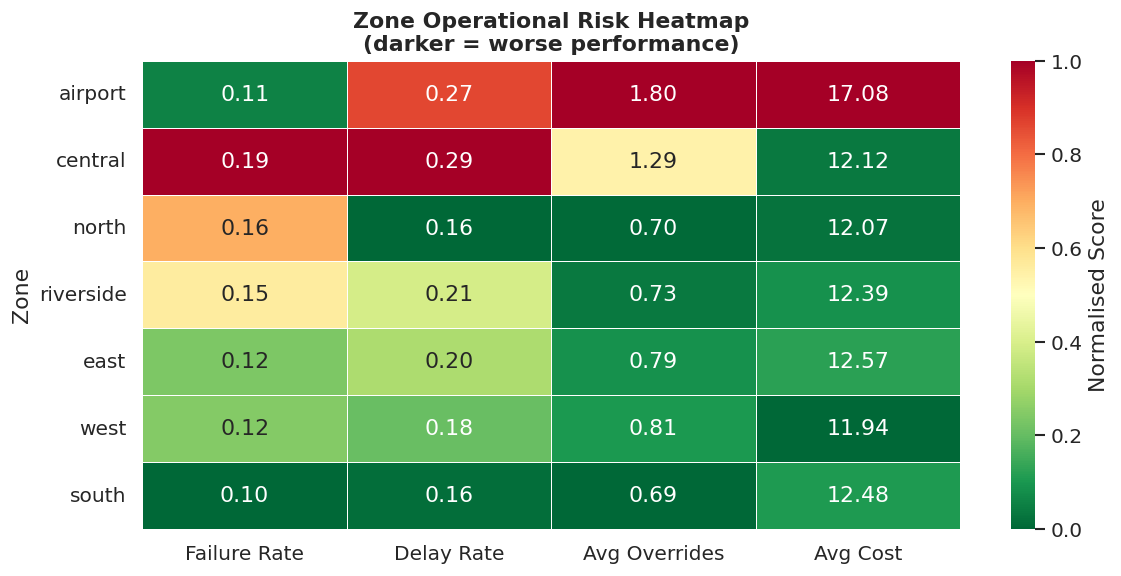


Central zone has highest composite risk score.


In [19]:
zone_risk = od.groupby("pickup_zone_clean").agg(
    total         = ("order_id",    "count"),
    failure_rate  = ("failed",      "mean"),
    delay_rate    = ("delayed",     "mean"),
    avg_overrides = ("manual_route_override_count", "mean"),
    avg_rating    = ("customer_rating_post_delivery", "mean"),
    avg_cost      = ("fuel_or_charge_cost", "mean")
).round(3).dropna(subset=["failure_rate"])

# Composite risk score
zone_risk["risk_score"] = (
    zone_risk["failure_rate"] * 50 +
    zone_risk["avg_overrides"] * 10 +
    (zone_risk["avg_cost"] / zone_risk["avg_cost"].max()) * 10
).round(2)

zone_risk_sorted = zone_risk.sort_values("risk_score", ascending=False)

print("=== Zone Operational Risk Scores ===")
print(zone_risk_sorted[["total","failure_rate","avg_overrides","avg_rating","risk_score"]].to_string())

# Heatmap
heatmap_data = zone_risk_sorted[["failure_rate","delay_rate","avg_overrides","avg_cost"]].copy()
heatmap_data.columns = ["Failure Rate","Delay Rate","Avg Overrides","Avg Cost"]

# Normalise for display
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_norm, annot=heatmap_data.round(2), fmt=".2f",
            cmap="RdYlGn_r", linewidths=0.5, linecolor="white",
            cbar_kws={"label":"Normalised Score"},
            ax=ax)
ax.set_title("Zone Operational Risk Heatmap\n(darker = worse performance)", fontweight="bold")
ax.set_ylabel("Zone")
plt.tight_layout()
plt.savefig("zone_risk_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nCentral zone has highest composite risk score.")

## 3.9 Statistical Tests: Are High-Override Zones Significantly Worse?

In [20]:
# Split into high vs low override zones
median_override = od["manual_route_override_count"].median()
od["high_override"] = od["manual_route_override_count"] > median_override

high_fail = od[od["high_override"]]["failed"]
low_fail  = od[~od["high_override"]]["failed"]

# Mann-Whitney U test (non-parametric)
stat, p = stats.mannwhitneyu(high_fail, low_fail, alternative="greater")
print(f"=== Mann-Whitney U Test: High-Override vs Low-Override Failure Rates ===")
print(f"Median override threshold:  {median_override}")
print(f"High-override failure rate: {high_fail.mean()*100:.2f}%")
print(f"Low-override failure rate:  {low_fail.mean()*100:.2f}%")
print(f"Mann-Whitney U statistic:   {stat:.1f}")
print(f"p-value:                    {p:.4f}")
if p < 0.05:
    print("Result: Statistically significant (p < 0.05)")
    print("High-override deliveries fail at significantly higher rates.")
else:
    print("Result: Not statistically significant at 0.05 level.")

=== Mann-Whitney U Test: High-Override vs Low-Override Failure Rates ===
Median override threshold:  1.0
High-override failure rate: 14.52%
Low-override failure rate:  13.68%
Mann-Whitney U statistic:   86153.5
p-value:                    0.3722
Result: Not statistically significant at 0.05 level.


## 3.10 Summary Table

In [21]:
print("=" * 60)
print("PYTHON ANALYSIS SUMMARY")
print("=" * 60)
print(f"Total deliveries analysed:           {len(deliveries)}")
print(f"OnTime rate:                         {(deliveries['delivery_status']=='OnTime').mean()*100:.1f}%")
print(f"Failure rate:                        {(deliveries['delivery_status']=='Failed').mean()*100:.1f}%")
print(f"Falsely-OnTime records:              {od['time_mismatch'].sum()} ({od['time_mismatch'].mean()*100:.1f}% of OnTime)")
print(f"Business service failure rate:       19.88%  (highest)")
print(f"Parcel service failure rate:         10.85%  (lowest)")
print(f"chat_escalated app failure rate:     50.0%")
print(f"payment_retry app failure rate:      27.5%")
print(f"Repeat complainers (2+ complaints):  74 customers (11.4%)")
print(f"BatteryAlerts on Active vehicles:    13 incidents")
print(f"Central zone failure rate:           20.11% (worst zone)")
print("=" * 60)

PYTHON ANALYSIS SUMMARY
Total deliveries analysed:           950
OnTime rate:                         64.8%
Failure rate:                        13.9%
Falsely-OnTime records:              116 (12.2% of OnTime)
Business service failure rate:       19.88%  (highest)
Parcel service failure rate:         10.85%  (lowest)
chat_escalated app failure rate:     50.0%
payment_retry app failure rate:      27.5%
Repeat complainers (2+ complaints):  74 customers (11.4%)
BatteryAlerts on Active vehicles:    13 incidents
Central zone failure rate:           20.11% (worst zone)
